# methylphenidate

> Central nervous system stimulant used in the treatment of attention deficit hyperactivity disorder (ADHD) and narcolepsy
>
> Also, a name of this project, because both of them help me build new neuron connections

## Abstract

This project is a proof-of-concept experiment of running neural networks on FPGA boards. I made myself a very small network, found tools to compile it into VHDL, and then successfully ran it on Artix-7

## FPGA? What's that?
FPGAs (field-programmable gate array) are configurable chips that, instead of implementing a concrete set of instructions like classical processors, allow you to configure the logic gates inside them at your needs.

Take your kitchen for an example - you have a toster, a frying pan, a microwave... you can cook whatever you want with them! But if I asked you to bake me a 100 of breads overnight, your oven would probably not make it

Meanwhile, your local bakery doesn't have microwaves or frying pans. They cannot make a simple soup. But they have one big oven that can make hundreds of breads every day!

Programming an FPGA is like building your own bakery 🍞

## Neural networks need a lot of bread

Neural networks (the algorithms behind all modern artificial intelligence) contain of many layers of "neurons". These neurons are very simple steps of math - they multiply and compare whatever number you give them, and pass them further. When all of that random math combines, at the end, they can do tasks that no exact algorythm could solve - like recognizing objects, human speech, or translating languages.

<img src="img/nn.png" width="300px">

On they own, neurons are very simple, identical steps - but there is A LOT of them. And this is where FPGAs could be extremely efficient - instead of telling CPU to calculate each neuron step by step, we can just bake **all neurons** into the FPGA.

That would allow to run them radically faster (nanoseconds instead of seconds), which is not just nice to have, but also allows us to use them in cases like audio processing, where anything above 1ms of lag distorts the audio with a hearable echo.

# Preparing the neural network

![](img/playground.png)

[Tensorflow Playground](https://playground.tensorflow.org/) is a great visual tool for learning about ML. Inspired by it, i recreated this f(X, Y)=orange/blue network in Keras, with pytorch as a backend:

In [2]:
import os

os.environ['KERAS_BACKEND'] = 'torch'

import numpy as np
import keras
from keras import layers

# Generate data in [-1, 1] range
np.random.seed(42)
n = 500

X = (np.random.rand(n, 2) * 2 - 1).astype('float32')  # uniform [-1, 1]
y = ((X[:, 0] * X[:, 1]) > 0).astype('int32')  # 1 if same sign (both + or both -)

In [3]:
# Model: 2 outputs with softmax
model = keras.Sequential([
    layers.Input(shape=(2,), name='przeInput'),
    layers.Dense(4, activation='tanh', name='hidden1'),
    layers.Dense(2, activation='softmax', name='przeOutput')
])
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(X, y, epochs=200, batch_size=50, verbose=0)
# Quick summary
loss, acc = model.evaluate(X, y, verbose=0)
print(f"Accuracy: {acc:.1%}")

Accuracy: 99.6%


## Let's test it!

It takes X and Y position, and outputs the probability of it being orange or blue. Let's try bottom-left corner - should be blue:

In [3]:
model.predict(np.array([[-0.5, -0.5]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


array([[2.7609306e-06, 9.9999726e-01]], dtype=float32)

1% for orange🟠, 99% for blue🔵 - perfect!

Then, I visualise all of its outputs just like the Playground does:

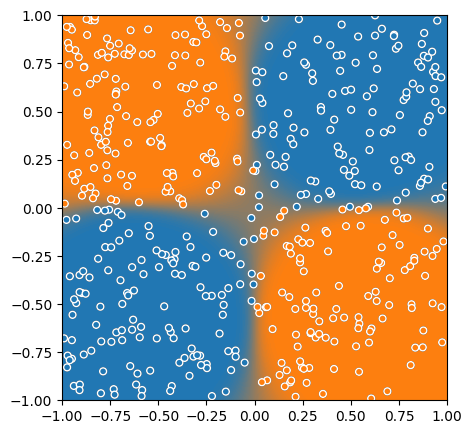

In [4]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Predict across the whole [-1, 1] grid for the background color
xx, yy = np.meshgrid(np.linspace(-1, 1, 200), np.linspace(-1, 1, 200))
grid = np.c_[xx.ravel(), yy.ravel()].astype('float32')
probs = model.predict(grid, verbose=0)[:, 1].reshape(xx.shape)

# Plot
cmap = LinearSegmentedColormap.from_list('playground', ['#ff7f0e', '#1f77b4'])

plt.figure(figsize=(5, 5))
plt.contourf(xx, yy, probs, levels=50, cmap=cmap, vmin=0, vmax=1)
plt.scatter(X[:, 0], X[:, 1], c=['white']*n, edgecolors='black', linewidths=0.5, s=30)  # dots
plt.scatter(X[:, 0], X[:, 1], c=['#ff7f0e' if c == 0 else '#1f77b4' for c in y], edgecolors='white', s=25)
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.gca().set_aspect('equal')
plt.axis('on')
plt.show()

# Compiling the network into VHDL

VHDL is a language for FPGAs. After some research, I found [`hsl4ml`](https://fastmachinelearning.org/hls4ml/) - powerful but easy to use Python project by FastML Foundation, an international group of researchers.

`hls4ml` uses HLS - high level synthesis. Different FPGA manufacturers have their own versions of this - for my Artix-7 board made by AMD, I had to install the latest version of Vitis IDE.

> The compilation outputs somewhat of a full Vitis project - but I wanted to keep with Vivado, so i specify the output directory as inside of my already-existing Vivado project

With that, you're ready to compile:

In [ ]:
import hls4ml

print('compiling to vhdl...')

config = hls4ml.utils.config_from_keras_model(model)

config['Backend'] = 'Vitis'
config['Part'] = 'xc7a35ticsg324-1L' # Artix-7
config['ClockPeriod'] = 10
config['IOType'] = 'io_parallel'
print(config)

hls_dir = './methylphenidate_vivado/methylphenidate_vivado.srcs/sources_1/new/medikinet'
hls_model = hls4ml.converters.convert_from_keras_model(
    model=model,
    output_dir=hls_dir,
    project_name='medikinet',
    backend='Vitis',
    hls_config=config,
)
hls_model.write()
hls_model.build()
hls4ml.report.read_vivado_report(hls_dir)

The output files contain all parts of the network, with the top-most interface inside `medikinet.vhd`

```
$ tree vhdl
vhdl/
├── medikinet_dense_latency_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_config2_s.vhd
├── medikinet_dense_latency_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_config4_s.vhd
├── medikinet_mul_16s_13ns_26_1_1.vhd
├── medikinet_mul_16s_13s_26_1_1.vhd
├── medikinet_mul_16s_14ns_26_1_1.vhd
├── medikinet_mul_16s_14s_26_1_1.vhd
├── medikinet_mul_18s_11ns_26_1_1.vhd
├── medikinet_softmax_stable_ap_fixed_ap_fixed_16_6_5_3_0_softmax_config5_s_exp_table_ROM_Acud.vhd
├── medikinet_softmax_stable_ap_fixed_ap_fixed_16_6_5_3_0_softmax_config5_s_invert_table_ROdEe.vhd
├── medikinet_softmax_stable_ap_fixed_ap_fixed_16_6_5_3_0_softmax_config5_s.vhd
├── medikinet_tanh_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_tanh_config3_s_tanh_table_ROM_AUbkb.vhd
├── medikinet_tanh_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_tanh_config3_s.vhd
└── medikinet.vhd
```

# Using the network

## The interface
The final interface is pretty straightforward:

```vhdl
-- medikinet.vhd
entity medikinet is
port (
    ap_clk : IN STD_LOGIC; -- Clock
    ap_rst : IN STD_LOGIC; -- Reset
    ap_start : IN STD_LOGIC; -- Start - set to 1 to start computing
    ap_done : OUT STD_LOGIC; -- "Network has finished computing"
    ap_idle : OUT STD_LOGIC;
    ap_ready : OUT STD_LOGIC;
    przeInput_ap_vld : IN STD_LOGIC;
    przeInput : IN STD_LOGIC_VECTOR (31 downto 0); -- Your input layer
    layer5_out_0 : OUT STD_LOGIC_VECTOR (15 downto 0); -- Orange output neuron
    layer5_out_0_ap_vld : OUT STD_LOGIC;
    layer5_out_1 : OUT STD_LOGIC_VECTOR (15 downto 0); -- Blue output neuron
    layer5_out_1_ap_vld : OUT STD_LOGIC );
end;
```

`hls4ml` uses `ap_fixed<16,6>`, which is a fixed-point number - 6 bits are used to store the whole number, and remaining 10 bits represent the fraction part. That's why neurons take 16 bits.

One caveat is that the input layer (all of its neurons) is joint into one vector, while outputs are separate, but that's not a big problem

### Converting human-written numbers to `ap_fixed`

With a simple function:
```vhdl
-- Converting floating point to fixed point that network requires
-- Fixed-point parameters: <16,6> means 10 fractional bits
constant FRAC_BITS : integer := 10;
constant SCALE     : real    := 2.0 ** FRAC_BITS;
function to_fixed(x : real) return std_logic_vector is
    variable scaled : integer;
begin
    scaled := integer(x * SCALE);
    return std_logic_vector(to_signed(scaled, 16));
end function;

-- Later, to prepare the input:
constant top_left_point := to_fixed(-0.5) & to_fixed( 0.5);
```

## Testing with 4 hard-coded points

I prepared 4 example points, and made the network analyze them in a loop:

```vhdl
constant points_array : t_point_arr := (
    to_fixed(-0.5) & to_fixed( 0.5), -- Top-left 🟠
    to_fixed( 0.5) & to_fixed( 0.5), -- Top-right 🔵
    to_fixed(-0.5) & to_fixed(-0.5), -- Bottom-left 🔵
    to_fixed( 0.5) & to_fixed(-0.5)  -- Bottom-right 🟠
);
```

![](img/test-4-wave.webp)

Orange🟠, blue🔵, blue🔵, orange🟠! Works correctly!

# Comparing the speed

Let's see if my promise about speed gains keeps true even with this small 4-neuron network

Calculating the output takes 7 clock cycles - that's 70ns with Artix' 1MHz clock.

Now, let's see how fast my laptop with AMD Ryzen 7 4700U can do it:

In [4]:
import time

# Calculate 500 random points at once
n = 500
X = (np.random.rand(n, 2) * 2 - 1).astype('float32')  # uniform [-1, 1]

# Do this 50 times
n_times = 50
times = []
for i in range(n_times):
  start = time.time()
  model.predict(X, verbose=0)
  end = time.time()
  times.append(end-start)
  time.sleep(0.1)

# And get the average of a single point
avg = sum(times) / n_times
single = avg/n

print(f"{single * 1000 * 1000}us")

66.9403076171875us


~60us! So the FPGA is 1000 times faster!

## Trying with more loafs 🥖

Let's try with an overkill, 8x64 neuron layers - that's 512 neurons:

In [5]:
# Model: 2 outputs with softmax
big_model = keras.Sequential([
    layers.Input(shape=(2,), name='przeInput'),
    layers.Dense(64, activation='tanh', name='hidden1'),
    layers.Dense(64, activation='tanh', name='hidden2'),
    layers.Dense(64, activation='tanh', name='hidden3'),
    layers.Dense(64, activation='tanh', name='hidden4'),
    layers.Dense(64, activation='tanh', name='hidden5'),
    layers.Dense(64, activation='tanh', name='hidden6'),
    layers.Dense(64, activation='tanh', name='hidden7'),
    layers.Dense(64, activation='tanh', name='hidden8'),
    layers.Dense(2, activation='softmax', name='przeOutput')
])
big_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
big_model.fit(X, y, epochs=100, batch_size=50, verbose=0)
# Quick summary
loss, acc = big_model.evaluate(X, y, verbose=0)
print(f"Accuracy: {acc:.1%}")

Accuracy: 49.8%


In [7]:
# Calculate 500 random points at once
n = 500
X = (np.random.rand(n, 2) * 2 - 1).astype('float32')  # uniform [-1, 1]

# Do this 50 times
n_times = 50
times = []
for i in range(n_times):
    start = time.time()
    big_model.predict(X, verbose=0)
    end = time.time()
    times.append(end-start)
    time.sleep(0.1)

# And get the average of a single point
avg = sum(times) / n_times
single = avg/n

print(f"{single * 1000 * 1000}us")

203.49836349487305us


200us - okay, let's see how FPGA will do:

In [ ]:
import hls4ml

print('compiling to vhdl...')

config = hls4ml.utils.config_from_keras_model(big_model)

config['Backend'] = 'Vitis'
config['Part'] = 'xc7a35ticsg324-1L' # Artix-7
config['ClockPeriod'] = 10
config['IOType'] = 'io_parallel'
print(config)

hls_dir = './methylphenidate_vivado/methylphenidate_vivado.srcs/sources_1/new/medikinet_cr'
hls_model = hls4ml.converters.convert_from_keras_model(
    model=big_model,
    output_dir=hls_dir,
    project_name='medikinet_cr',
    backend='Vitis',
    hls_config=config,
)
hls_model.write()
hls_model.build()
hls4ml.report.read_vivado_report(hls_dir)

> Note: `hls4ml` compilation took waaay longer now - whole 40 minutes

Let's run the simulation:

![](img/test-512-wave.png)

It takes 440ns (44 clock cycles) to process the bigger network - so this time, my laptop's 200us are 500x slower, not 1000x.

# Summary 🧑‍🍳

Even tho the setup of the framework wasn't painless (that was mainly because of AMD's proprietary ecosystem) - the `hls4ml` package was very easy to use. Thanks to it, running a custom neural network is even easier than most of the tasks you usually do on FPGAs.

## The speed

My speed comparisons were, of course, very unfair and unprecise. The FPGA is running *only* my network, purely bere-metal - while the network on my laptop was running on top of full OS, in userspace, in Python (the slowest language known to mankind).

Still, 440ns (half a millisecond) for 512 weight network - is very impressive

# Thank you for reading 🩵

Mateusz Soszyński, 282935 (at) pwr.edu.pl